In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
path = "../data/processed/kegg_module_membership.tsv"

m = pd.read_csv(path, sep="\t")
print(m.shape)
assert set(m["member_type"]) <= {"gene", "metabolite"}
assert m["module_id"].str.fullmatch(r"M\d{5}").all()

(1397, 3)


In [3]:
mods = m.groupby("module_id")["member_type"].agg(set)
funnel = pd.Series({
    "gene_only": (mods == {"gene"}).sum(),
    "metabolite_only": (mods == {"metabolite"}).sum(),
    "both": (mods == {"gene", "metabolite"}).sum(),
})

print("Module composition")
print(funnel)
print("Total:", funnel.sum())

assert funnel.sum() == 258

print(
    "\nInterpretation: this describes composition only; "
    "gene-only and metabolite-only modules remain in post-hoc analyses."
)

Module composition
gene_only           77
metabolite_only    127
both                54
dtype: int64
Total: 258

Interpretation: this describes composition only; gene-only and metabolite-only modules remain in post-hoc analyses.


In [4]:
total = m.groupby("module_id").size()

genes = (
    m[m.member_type == "gene"]
    .groupby("module_id")
    .size()
    .reindex(total.index, fill_value=0)
)

metabs = (
    m[m.member_type == "metabolite"]
    .groupby("module_id")
    .size()
    .reindex(total.index, fill_value=0)
)

summary = pd.DataFrame({
    "module_id": total.index,
    "n_total": total.values,
    "n_gene": genes.values,
    "n_metabolite": metabs.values,
})

summary["modality_class"] = (
    summary[["n_gene", "n_metabolite"]]
    .apply(
        lambda r:
        "gene_only" if (r.n_gene > 0 and r.n_metabolite == 0)
        else "metabolite_only" if (r.n_gene == 0 and r.n_metabolite > 0)
        else "both",
        axis=1
    )
)

display(summary.head())

,module_id,n_total,n_gene,n_metabolite,modality_class
0,M00001,28,26,2,both
1,M00002,15,13,2,both
2,M00003,20,18,2,both
3,M00004,14,12,2,both
4,M00005,3,3,0,gene_only


In [5]:
rows = []

for t in [2, 3, 5, 10]:
    rows.append({
        "threshold": t,
        "total": (summary.n_total >= t).sum(),
        "gene_side": (summary.n_gene >= t).sum(),
        "metabolite_side": (summary.n_metabolite >= t).sum(),
    })

coverage = pd.DataFrame(rows)

display(coverage)

print(
    "\nInterpretation: metabolite coverage is expected to collapse quickly "
    "at higher thresholds because only 71 compounds are represented in-module."
)

,threshold,total,gene_side,metabolite_side
0,2,195,129,97
1,3,140,117,32
2,5,101,84,7
3,10,50,44,0



Interpretation: metabolite coverage is expected to collapse quickly at higher thresholds because only 71 compounds are represented in-module.


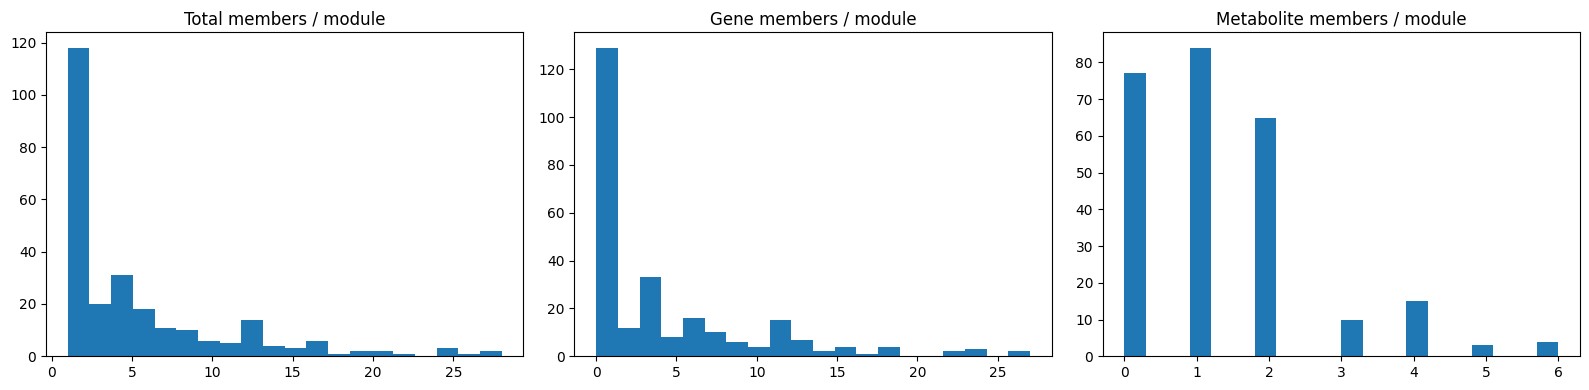

Metabolite counts are sparse by construction (targeted assay; 71 in-module compounds), which is a property of the dataset rather than a QC issue.


,n_total,n_gene,n_metabolite
count,258.000000,258.000000,258.000000
mean,5.414729,4.085271,1.329457
std,5.611489,5.762526,1.303984
min,1.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000
50%,3.000000,1.500000,1.000000
75%,7.000000,6.000000,2.000000
max,28.000000,27.000000,6.000000


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(summary["n_total"], bins=20)
axes[0].set_title("Total members / module")

axes[1].hist(summary["n_gene"], bins=20)
axes[1].set_title("Gene members / module")

axes[2].hist(summary["n_metabolite"], bins=20)
axes[2].set_title("Metabolite members / module")

plt.tight_layout()
plt.show()

print(
    "Metabolite counts are sparse by construction "
    "(targeted assay; 71 in-module compounds), "
    "which is a property of the dataset rather than a QC issue."
)

display(
    summary[["n_total", "n_gene", "n_metabolite"]]
    .describe()
)

## Coverage summary and caveats

**Module composition (258 modules detected in data):**
- gene-only: 77
- metabolite-only: 127
- both modalities: 54

The funnel is descriptive, not a selector. Every module meeting the member
threshold enters the post-hoc analysis regardless of modality composition,
gene-only and metabolite-only modules are retained. This is the deliberate
departure from the prior constrained design, which down-selected to
both-modality modules.

**Coverage by threshold:**

| threshold | total | gene side | metabolite side |
|-----------|-------|-----------|-----------------|
| ≥2        | 195   | 129       | 97              |
| ≥3        | 140   | 117       | 32              |
| ≥5        | 101   | 84        | 7               |
| ≥10       | 50    | 44        | 0               |

The metabolite side collapses past ≥3 (32 → 7 → 0). This is structural: only
71 compounds appear in any module, so metabolite-bearing modules are sparse by
construction (targeted assay, not a QC defect). The gene side is exact
(Entrez-keyed, no symbol ambiguity); the metabolite side is the lossy one
(name → KEGG compound ID, ~50% mappable).

**Implications for Day 4:**
- A ≥3 headline threshold is well-supported on the total and gene sides (140
  and 117 modules), so the primary claim has ample modules.
- Any analysis requiring metabolite members is thin above ≥3 (32 modules at
  ≥3, 7 at ≥5). The both-modality pool for the secondary cross-modality check
  is 54 modules total and shrinks with threshold. This is why the prereg must
  specify within-modality vs all-pairs cosine for mixed modules.

**Upper-bound caveat:** all counts here are over the full QC'd gene panel and
the current mapped-metabolite set. Final member counts are fixed at Week 10,
after top-5000 gene selection (Week 4) and Entrez → UniProt reconciliation
(Week 8). Member counts can only shrink from here, so thresholds are read
against numbers that will decrease, the 2/3/5 sensitivity sweep absorbs this.

In [2]:
import h5py
import numpy as np

def read_df_h5(group):
    data = group["data"][:]                
    cols = group["columns"][:].astype(str)        
    return data, cols                             

path = "../data/processed/omics_clean.h5"
with h5py.File(path, "r") as f:
    tx, tx_cols = read_df_h5(f["tx_clean"])
    mt, mt_cols = read_df_h5(f["mt_clean"])

print("tx:", tx.shape, "| mt:", mt.shape)

tx: (904, 19205) | mt: (904, 225)


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

tx_standardized = StandardScaler().fit_transform(tx)
tx_pca = PCA().fit(tx_standardized)
tx_cumulative = np.cumsum(tx_pca.explained_variance_ratio_)

mt_standardized = StandardScaler().fit_transform(mt)
mt_pca = PCA().fit(mt_standardized)
mt_cumulative = np.cumsum(mt_pca.explained_variance_ratio_)

In [6]:
tx_80 = int(np.argmax(tx_cumulative >= 0.80) + 1)
tx_90 = int(np.argmax(tx_cumulative >= 0.90) + 1)
mt_80 = int(np.argmax(mt_cumulative >= 0.80) + 1)
mt_90 = int(np.argmax(mt_cumulative >= 0.90) + 1)

print(f"Transcriptomics:  {tx_80} PCs to 80%   |   {tx_90} PCs to 90%")
print(f"Metabolomics:     {mt_80} PCs to 80%   |   {mt_90} PCs to 90%")

Transcriptomics:  285 PCs to 80%   |   490 PCs to 90%
Metabolomics:     44 PCs to 80%   |   80 PCs to 90%


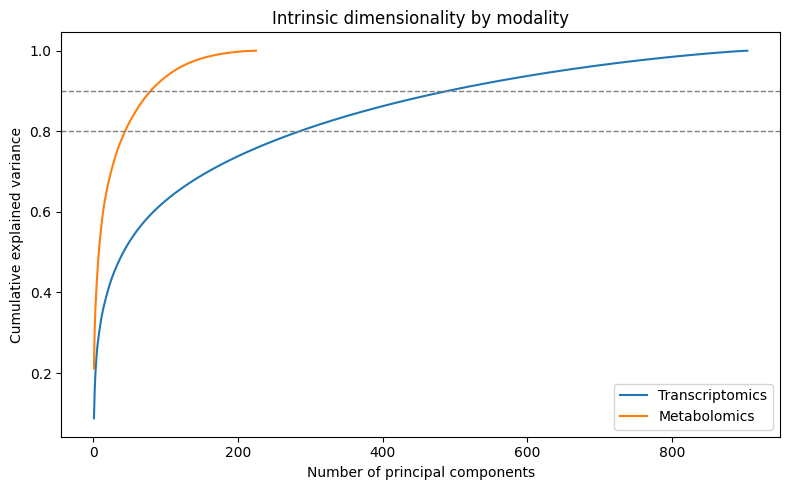

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(range(1, len(tx_cumulative) + 1), tx_cumulative, label="Transcriptomics")
ax.plot(range(1, len(mt_cumulative) + 1), mt_cumulative, label="Metabolomics")

ax.axhline(0.80, linestyle="--", color="gray", linewidth=1)
ax.axhline(0.90, linestyle="--", color="gray", linewidth=1)

ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Intrinsic dimensionality by modality")
ax.legend()

plt.tight_layout()
plt.show()

## Per-modality dimensionality and encoder-depth decision (draft)

PCs to reach cumulative variance, full clean feature set, z-scored:

| modality        | 80% | 90% |
|-----------------|-----|-----|
| transcriptomics | 285 | 490 |
| metabolomics    |  44 |  80 |

Transcriptomics needs ~6x the components of metabolomics to reach the same
variance target. Metabolomics variance concentrates in few PCs (44 to 80%);
transcriptomics is spread across hundreds (285 to 80%). The two modalities
have different intrinsic dimensionality.

**Decision:**
- Transcriptomics encoder: deeper (more nonlinear capacity to compress a
  high-dimensional input toward the shared latent).
- Metabolomics encoder: shallow (variance lives in ~50 PCs; a deep stack would
  overfit 225 features on 904 samples).

**Caveats:**
- Absolute PC counts are indicative, not the model-input dimensionality. PCA ran
  on all 19205 genes; the model sees top-5000 (Week 4). The top-5000 will need
  fewer PCs, but still far more than metabolomics, the *relative gap* is robust
  to the subset, which is what justifies the encoder asymmetry.
- PCA justifies deep-vs-shallow only. The specific hidden dimensions are a
  modeling choice set in D011, not dictated by these numbers.